In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
import zipfile
import os

zip_path = "archive (2).zip"
extract_folder = "jm1_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

df = pd.read_csv("jm1_dataset/jm1.csv")

df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (10885, 22)

Column Names:
['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            108

In [6]:
df.describe()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment
count,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,1.088500e+04,10885.000000,1.088500e+04,10885.000000,10885.000000,10885.00000,10885.000000
mean,42.016178,6.348590,3.401047,4.001599,114.389738,673.758017,0.135335,14.177237,29.439544,3.683637e+04,0.224766,2.046465e+03,26.252274,2.737529,4.62554,0.370785
std,76.593332,13.019695,6.771869,9.116889,249.502091,1938.856196,0.160538,18.709900,34.418313,4.343678e+05,0.646408,2.413154e+04,59.611201,9.008608,9.96813,1.907969
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,11.000000,2.000000,1.000000,1.000000,14.000000,48.430000,0.030000,3.000000,11.860000,1.619400e+02,0.020000,9.000000e+00,4.000000,0.000000,0.00000,0.000000
50%,23.000000,3.000000,1.000000,2.000000,49.000000,217.130000,0.080000,9.090000,21.930000,2.031020e+03,0.070000,1.128300e+02,13.000000,0.000000,2.00000,0.000000
75%,46.000000,7.000000,3.000000,4.000000,119.000000,621.480000,0.160000,18.900000,36.780000,1.141643e+04,0.210000,6.342500e+02,28.000000,2.000000,5.00000,0.000000
max,3442.000000,470.000000,165.000000,402.000000,8441.000000,80843.080000,1.300000,418.200000,569.780000,3.107978e+07,26.950000,1.726655e+06,2824.000000,344.000000,447.00000,108.000000


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1973


In [9]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8912, 22)


In [10]:
print(df["defects"].value_counts())

defects
False    6905
True     2007
Name: count, dtype: int64


In [11]:
df["defects"] = df["defects"].astype(str).str.strip().str.lower()

df["defects"] = df["defects"].map({
    "true": 1,
    "false": 0
})

print(df["defects"].value_counts())

defects
0    6905
1    2007
Name: count, dtype: int64


In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


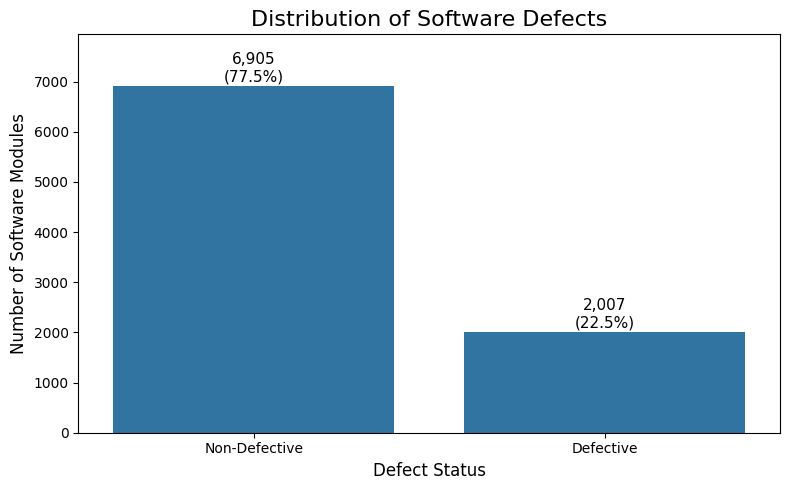

In [13]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x="defects",
    data=df
)

plt.title("Distribution of Software Defects", fontsize=16)
plt.xlabel("Defect Status", fontsize=12)
plt.ylabel("Number of Software Modules", fontsize=12)

plt.xticks(
    [0, 1],
    ["Non-Defective", "Defective"]
)

# Add count and percentage labels
total = len(df)

for bar in ax.patches:
    count = int(bar.get_height())
    percentage = (count / total) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + 100,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.ylim(0, max(df["defects"].value_counts()) * 1.15)

plt.tight_layout()
plt.show()

In [14]:
defect_percentage = df["defects"].value_counts(normalize=True) * 100

print("Defect Distribution (%):")
print(defect_percentage)

Defect Distribution (%):
defects
0    77.479803
1    22.520197
Name: proportion, dtype: float64


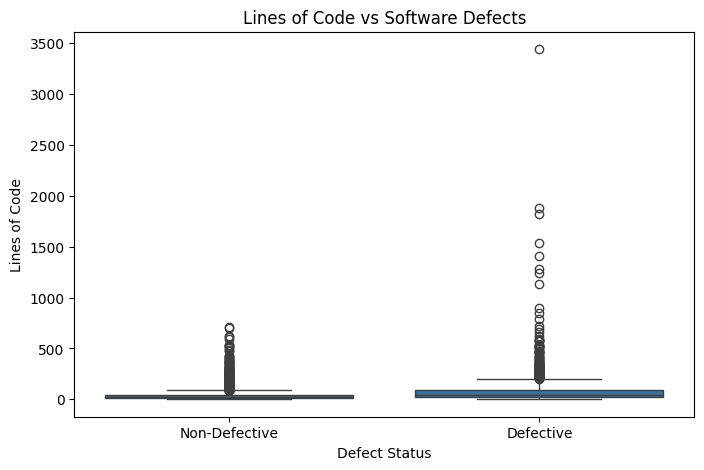

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="defects",
    y="loc",
    data=df
)

plt.title("Lines of Code vs Software Defects")
plt.xlabel("Defect Status")
plt.ylabel("Lines of Code")
plt.xticks([0, 1], ["Non-Defective", "Defective"])

plt.show()

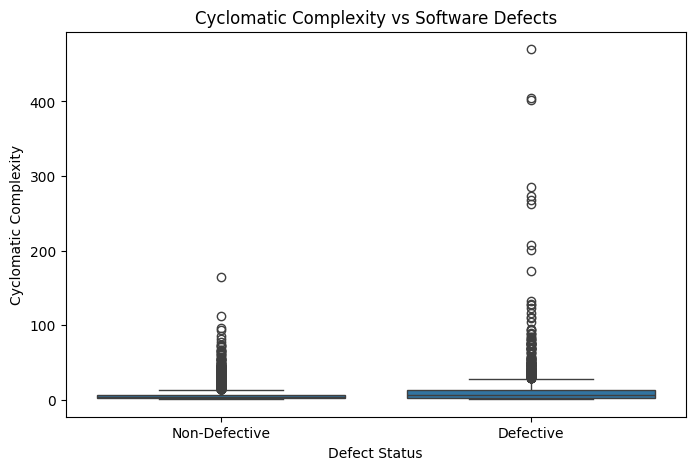

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="defects",
    y="v(g)",
    data=df
)

plt.title("Cyclomatic Complexity vs Software Defects")
plt.xlabel("Defect Status")
plt.ylabel("Cyclomatic Complexity")
plt.xticks([0, 1], ["Non-Defective", "Defective"])

plt.show()

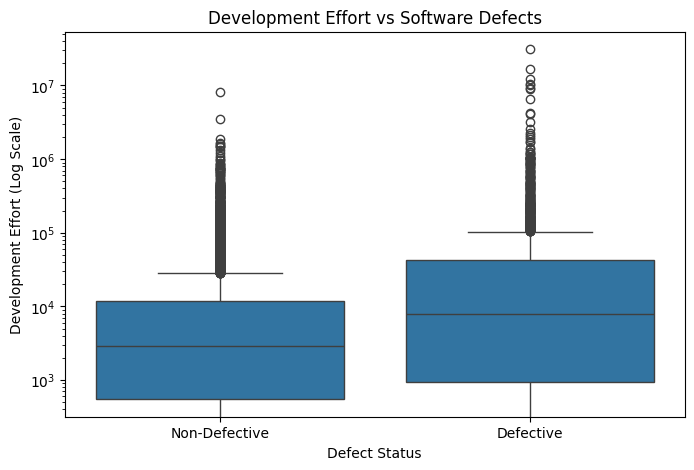

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="defects",
    y=pd.to_numeric(df["e"], errors="coerce"),
    data=df
)

plt.yscale("log")

plt.title("Development Effort vs Software Defects")
plt.xlabel("Defect Status")
plt.ylabel("Development Effort (Log Scale)")
plt.xticks([0, 1], ["Non-Defective", "Defective"])

plt.show()

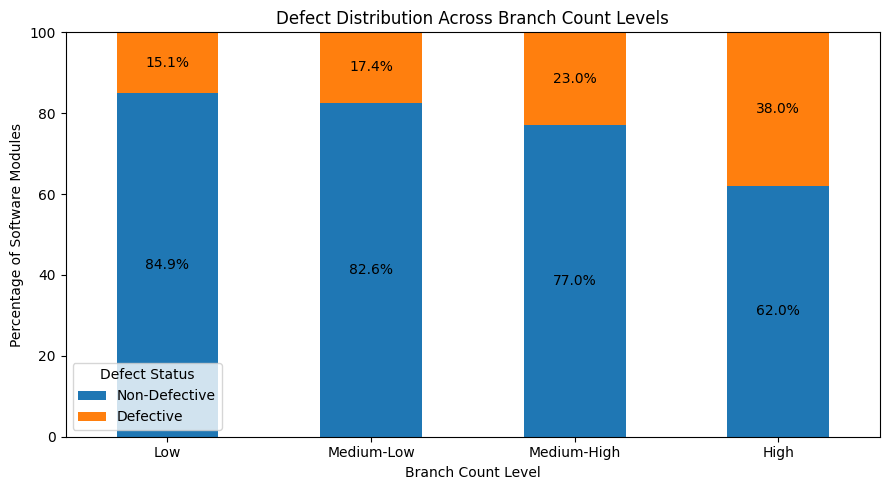

In [18]:
plot_df = df.copy()

plot_df["branchCount"] = pd.to_numeric(
    plot_df["branchCount"],
    errors="coerce"
)

plot_df = plot_df.dropna(subset=["branchCount"])

plot_df["Branch Group"] = pd.qcut(
    plot_df["branchCount"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"],
    duplicates="drop"
)

defect_percent = pd.crosstab(
    plot_df["Branch Group"],
    plot_df["defects"],
    normalize="index"
) * 100

# Plot
ax = defect_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Defect Distribution Across Branch Count Levels")
plt.xlabel("Branch Count Level")
plt.ylabel("Percentage of Software Modules")
plt.xticks(rotation=0)
plt.legend(
    ["Non-Defective", "Defective"],
    title="Defect Status"
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() > 5 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

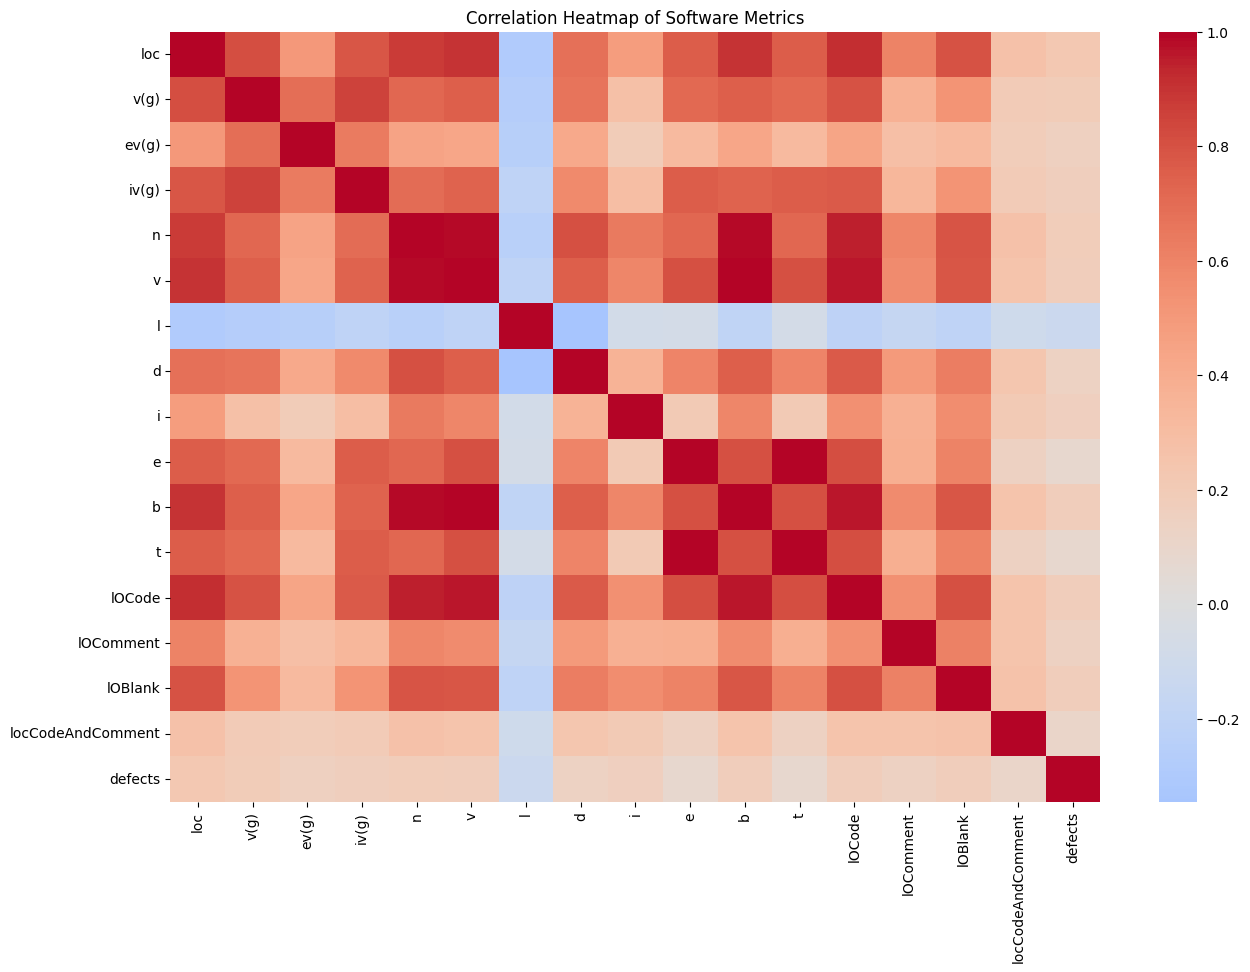

In [19]:
plt.figure(figsize=(15, 10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Software Metrics")

plt.show()

In [20]:
defect_correlation = correlation["defects"].sort_values(
    ascending=False
)

print("Correlation with Software Defects:")
print(defect_correlation)

Correlation with Software Defects:
defects              1.000000
loc                  0.224833
v(g)                 0.191450
n                    0.184597
lOBlank              0.177874
lOCode               0.177007
b                    0.174139
v                    0.173984
iv(g)                0.168240
i                    0.163717
ev(g)                0.157489
lOComment            0.146006
d                    0.139824
locCodeAndComment    0.109063
t                    0.083198
e                    0.083198
l                   -0.125540
Name: defects, dtype: float64


In [21]:
X = df.drop("defects", axis=1)
y = df["defects"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (8912, 21)
Target: (8912,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (7129, 21)
Testing set: (1783, 21)


In [23]:

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Data preprocessing completed.")
print("Missing values in training data:", X_train.isnull().sum().sum())
print("Missing values in testing data:", X_test.isnull().sum().sum())

Data preprocessing completed.
Missing values in training data: 0
Missing values in testing data: 0


In [24]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [25]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.6725
Precision: 0.3537
Recall   : 0.5473
F1 Score : 0.4297


In [27]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Defective", "Defective"]
    )
)

               precision    recall  f1-score   support

Non-Defective       0.84      0.71      0.77      1381
    Defective       0.35      0.55      0.43       402

     accuracy                           0.67      1783
    macro avg       0.60      0.63      0.60      1783
 weighted avg       0.73      0.67      0.69      1783



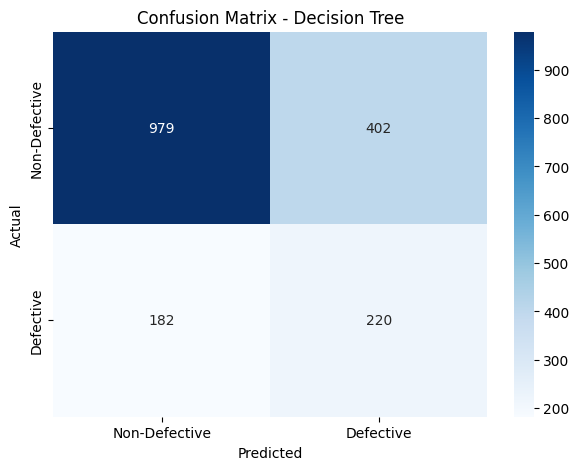

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Defective", "Defective"],
    yticklabels=["Non-Defective", "Defective"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
loc                  0.278363
d                    0.079550
i                    0.061416
lOBlank              0.060796
total_Op             0.059773
v                    0.048711
total_Opnd           0.046443
uniq_Opnd            0.042609
lOCode               0.040035
uniq_Op              0.039924
n                    0.032931
iv(g)                0.030629
locCodeAndComment    0.027774
ev(g)                0.027486
lOComment            0.027312
e                    0.025606
branchCount          0.024748
t                    0.024702
v(g)                 0.011205
b                    0.006288
l                    0.003697
dtype: float64


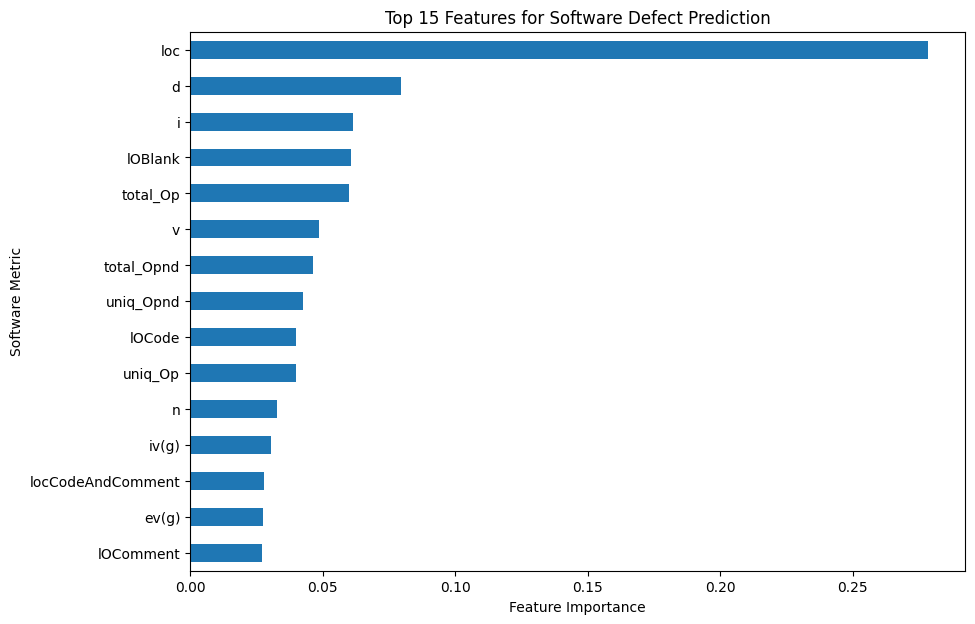

In [30]:
plt.figure(figsize=(10, 7))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features for Software Defect Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Software Metric")

plt.show()

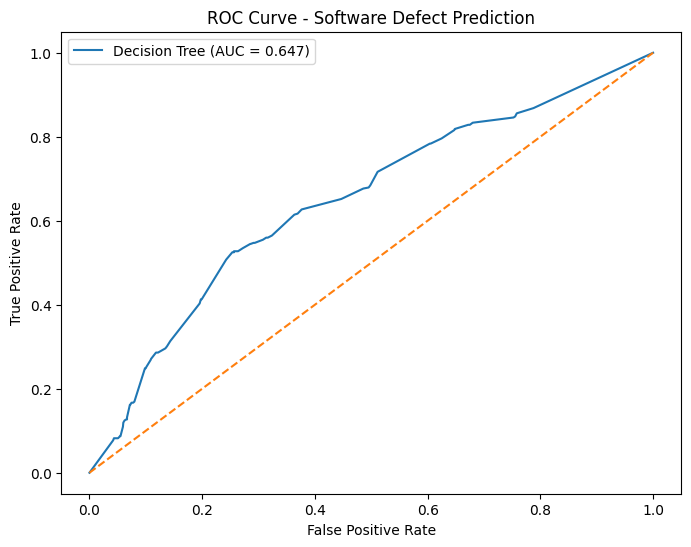

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Software Defect Prediction")

plt.legend()

plt.show()

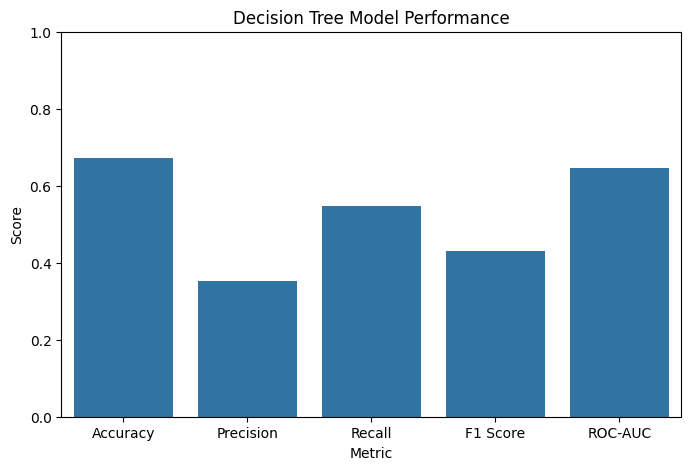

In [32]:
performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Metric",
    y="Score",
    data=performance
)

plt.ylim(0, 1)

plt.title("Decision Tree Model Performance")
plt.ylabel("Score")

plt.show()

In [33]:
performance

,Metric,Score
0,Accuracy,0.672462
1,Precision,0.353698
2,Recall,0.547264
3,F1 Score,0.429688
4,ROC-AUC,0.647172


In [34]:
print("Top 10 Factors Associated with Software Defects:\n")

for feature, importance in feature_importance.head(10).items():
    print(f"{feature}: {importance:.4f}")

Top 10 Factors Associated with Software Defects:

loc: 0.2784
d: 0.0796
i: 0.0614
lOBlank: 0.0608
total_Op: 0.0598
v: 0.0487
total_Opnd: 0.0464
uniq_Opnd: 0.0426
lOCode: 0.0400
uniq_Op: 0.0399


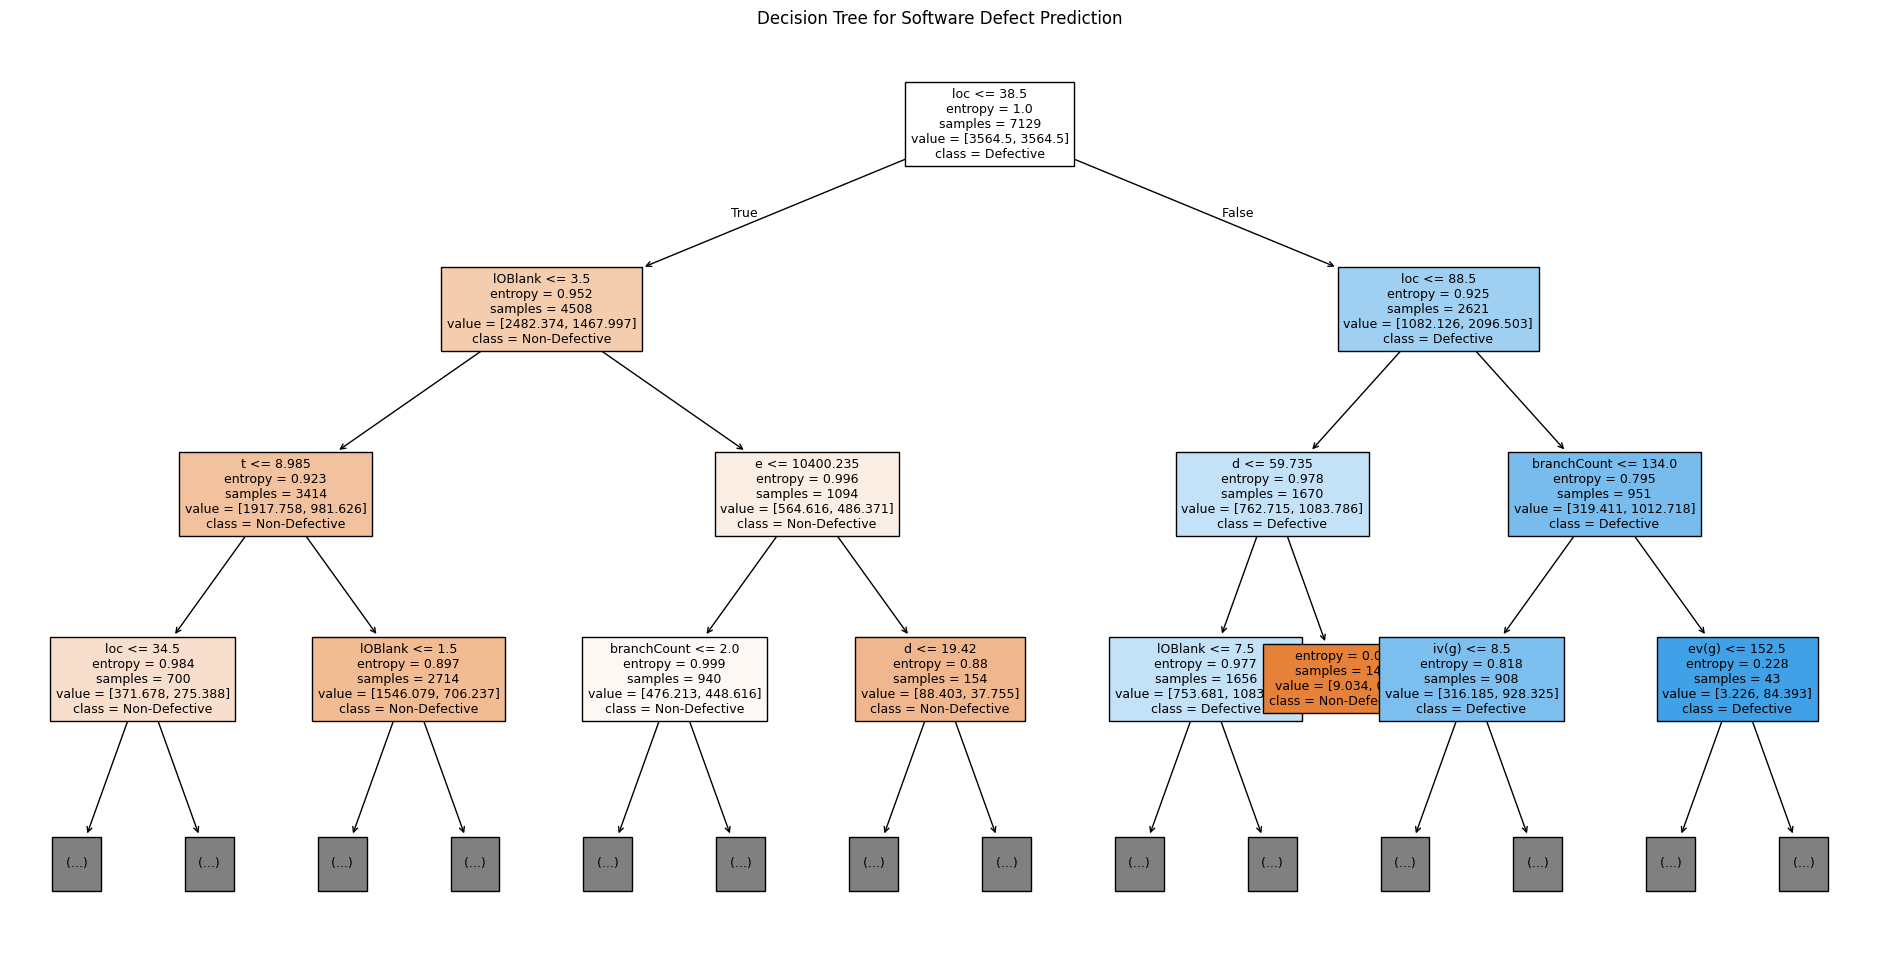

In [35]:
plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Non-Defective", "Defective"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree for Software Defect Prediction")

plt.show()

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Final Model Analysis
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred, zero_division=0)
final_recall = recall_score(y_test, y_pred, zero_division=0)
final_f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 60)
print("        SOFTWARE DEFECT PREDICTION - FINAL ANALYSIS")
print("=" * 60)

print("\nMODEL USED")
print("-" * 60)
print("Algorithm        : Decision Tree Classifier")
print("Best Parameters  :", grid.best_params_)

print("\nMODEL PERFORMANCE")
print("-" * 60)
print(f"Cross-Validation Accuracy : {grid.best_score_ * 100:.2f}%")
print(f"Test Accuracy             : {final_accuracy * 100:.2f}%")
print(f"Precision                 : {final_precision * 100:.2f}%")
print(f"Recall                    : {final_recall * 100:.2f}%")
print(f"F1-Score                  : {final_f1 * 100:.2f}%")

print("\nDATASET ANALYSIS")
print("-" * 60)
print(f"Total Modules     : {len(df)}")
print(f"Training Samples  : {len(X_train)}")
print(f"Testing Samples   : {len(X_test)}")
print(f"Number of Features: {X_train.shape[1]}")

print("\nDEFECT DISTRIBUTION")
print("-" * 60)
print(f"Non-Defective : {(df['defects'] == 0).sum()}")
print(f"Defective     : {(df['defects'] == 1).sum()}")

print("\nTOP FEATURES ASSOCIATED WITH DEFECTS")
print("-" * 60)

for feature, importance in feature_importance.head(5).items():
    print(f"{feature:<20} {importance:.4f}")

print("\nKEY FINDINGS")
print("-" * 60)
print("• Software complexity metrics are associated with defect occurrence.")
print("• LOC and cyclomatic complexity show noticeable relationships with defects.")
print("• Feature importance helps identify the most influential software metrics.")
print("• The Decision Tree provides an interpretable classification model.")
print("• The model can be used to identify modules that may require additional testing.")

print("\nCONCLUSION")
print("-" * 60)
print(f"The Decision Tree achieved {final_accuracy * 100:.2f}% test accuracy.")
print("The analysis demonstrates how software metrics can be")
print("used to predict whether a software module is likely to contain defects.")

print("=" * 60)

        SOFTWARE DEFECT PREDICTION - FINAL ANALYSIS

MODEL USED
------------------------------------------------------------
Algorithm        : Decision Tree Classifier
Best Parameters  : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

MODEL PERFORMANCE
------------------------------------------------------------
Cross-Validation Accuracy : 78.08%
Test Accuracy             : 77.90%
Precision                 : 56.67%
Recall                    : 8.46%
F1-Score                  : 14.72%

DATASET ANALYSIS
------------------------------------------------------------
Total Modules     : 8912
Training Samples  : 7129
Testing Samples   : 1783
Number of Features: 21

DEFECT DISTRIBUTION
------------------------------------------------------------
Non-Defective : 6905
Defective     : 2007

TOP FEATURES ASSOCIATED WITH DEFECTS
------------------------------------------------------------
loc                  0.2784
d                    0.0796
i             